In [84]:
import pandas as pd
import numpy as np
pd.options.display.max_rows = 1000
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.model_selection import permutation_test_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pickle
import os
from collections import Counter

import sys
sys.path.append("../../code")
import interpretability

In [85]:
response_var = "responder"
response_var_cap = "Responder"
conditions = "mdd_bp"
conditions_cap = "MDD Bandpower"
eval_metric = "nppv"
eval_metric_cap = "nPPV"
# conditions = "mdd_pooledbp_nopca"
# conditions_cap = "MDD Pooled (No PCA) Bandpower "

In [86]:
# BANDPOWER
# load in bandpower data
bandpower_df = pd.read_pickle('../../data/mdd_rtms_bandpower_all.pkl')
print("Bandpower dataframe shape:", bandpower_df.shape) # 128 subjects, 1 + (ec/eo) x num_electrodes x num_bands

# apply PCA on bandpower data to get top 90% components
numeric_df = bandpower_df.select_dtypes(include='number')

pca = PCA(n_components=0.9)
principal_components = pca.fit_transform(numeric_df)
n_pcs = principal_components.shape[1]

# create DataFrame
pca_df = pd.DataFrame(
    principal_components, 
    columns=[f'PC{i+1}' for i in range(n_pcs)]
)
pca_df['participants_ID'] = bandpower_df['participants_ID'].values
print("Top PCs dataframe shape:", pca_df.shape)
print(pca_df.head())

# optional: plot cumulative variance across the PCs
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-')
# plt.xlabel('Number of Principal Components', fontsize=12)
# plt.ylabel('Cumulative Explained Variance', fontsize=12)
# plt.title('Explained Variance vs. Number of Principal Components', fontsize=14)
# plt.xticks(range(1, len(cumulative_variance)+1))
# plt.yticks(np.arange(0, 1.05, 0.1))
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

Bandpower dataframe shape: (128, 365)
Top PCs dataframe shape: (128, 16)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.456554 -0.218373 -0.069308  0.048824  0.627367 -0.144422  0.197812   
1  0.598108  0.401997 -0.288402  0.420649 -0.222144 -0.160556  0.007264   
2  1.195718  0.422061 -0.032820  0.722472  0.186482  0.087547 -0.258043   
3  1.120544 -0.128459 -0.605335 -0.159502  0.427999 -0.019858  0.167473   
4 -0.829465 -0.841485  0.490047 -0.200865  0.146694 -0.471460 -0.294551   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.367607 -0.149389 -0.024303  0.043855  0.036421  0.005111  0.074891   
1  0.326445  0.256525  0.164097  0.217647 -0.004974  0.027013 -0.036508   
2 -0.012536  0.157819 -0.192613  0.077461  0.224517  0.033808  0.064575   
3  0.039179 -0.211827 -0.284801  0.173746  0.048207 -0.090028 -0.018780   
4 -0.039343 -0.246194 -0.104846 -0.048388 -0.023751 -0.213030  0.073375   

       PC15 participants_

In [87]:
# # BANDPOWER POOLED
# # load in bandpower data
# pooled_bp_df = pd.read_pickle('../../data/mdd_rtms_bandpower_pooled.pkl')
# print("Pooled bandpower dataframe shape:", pooled_bp_df.shape) # 128 subjects, 1 + (ec/eo) x num_regions x num_bands

# pca_df = pooled_bp_df

# # apply PCA to get top 90% components
# numeric_df = pooled_bp_df.select_dtypes(include='number')

# pca = PCA(n_components=0.9)
# principal_components = pca.fit_transform(numeric_df)
# n_pcs = principal_components.shape[1]

# # create DataFrame
# pca_df = pd.DataFrame(
#     principal_components, 
#     columns=[f'PC{i+1}' for i in range(n_pcs)]
# )
# pca_df['participants_ID'] = pooled_bp_df['participants_ID'].values
# print("Top PCs dataframe shape:", pca_df.shape)
# print(pca_df.head())

# # optional: plot cumulative variance across the PCs
# # cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# # plt.figure(figsize=(8,5))
# # plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-')
# # plt.xlabel('Number of Principal Components', fontsize=12)
# # plt.ylabel('Cumulative Explained Variance', fontsize=12)
# # plt.title('Explained Variance vs. Number of Principal Components', fontsize=14)
# # plt.xticks(range(1, len(cumulative_variance)+1))
# # plt.yticks(np.arange(0, 1.05, 0.1))
# # plt.grid(True, linestyle='--', alpha=0.5)
# # plt.show()

### Merge dataframes

In [88]:
demographic_df = pd.read_csv(f"../../data/final_dataset_{response_var}.csv")
demographic_df.head()
print("Demographic dataframe shape:", demographic_df.shape)

duplicate_ids = demographic_df["participants_ID"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1].index
demographic_df = demographic_df.drop_duplicates(subset="participants_ID", keep="first")
print("Shape after keeping only first entry for each participant for demographic_df:", demographic_df.shape)

duplicate_ids = pca_df["participants_ID"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1].index
pca_df = pca_df.drop_duplicates(subset="participants_ID", keep="first")
print("Shape after keeping only first entry for each participant for pca_df:", pca_df.shape)

# df = pd.merge(bandpower_top_few_df, demographic_df, on='participants_ID', how='inner')
df = pd.merge(pca_df, demographic_df, on='participants_ID', how='inner')
print("Merged dataframe shape:", df.shape)
print(df.head())

Demographic dataframe shape: (230, 114)
Shape after keeping only first entry for each participant for demographic_df: (215, 114)
Shape after keeping only first entry for each participant for pca_df: (120, 16)
Merged dataframe shape: (120, 129)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.456554 -0.218373 -0.069308  0.048824  0.627367 -0.144422  0.197812   
1  0.598108  0.401997 -0.288402  0.420649 -0.222144 -0.160556  0.007264   
2  1.195718  0.422061 -0.032820  0.722472  0.186482  0.087547 -0.258043   
3  1.120544 -0.128459 -0.605335 -0.159502  0.427999 -0.019858  0.167473   
4 -0.829465 -0.841485  0.490047 -0.200865  0.146694 -0.471460 -0.294551   

        PC8       PC9      PC10  ...  ever_used_cigarette  \
0  0.367607 -0.149389 -0.024303  ...                  0.0   
1  0.326445  0.256525  0.164097  ...                  0.0   
2 -0.012536  0.157819 -0.192613  ...                  1.0   
3  0.039179 -0.211827 -0.284801  ...                  0.0   


### Preprocessing & splitting

In [128]:
demographic_cols = ['age', 'gender', 'education', 'BDI_pre', 'ever_used_drugs']
bandpower_cols = df.filter(regex='_power$').columns.tolist()
pca_cols = df.filter(regex='PC').columns.tolist()

# construct X
# X = df[demographic_cols + bandpower_cols + pca_cols]
X = df[demographic_cols]
y = df[response_var_cap]

# binary vars float --> str
X = X.copy()
X['gender'] = X['gender'].map({1.0: 'male', 0.0: 'female'})

print("X shape:", X.shape)
print("X columns:", X.columns)
# print("X column datatypes:", X.dtypes)
# print(X.head())

X shape: (120, 5)
X columns: Index(['age', 'gender', 'education', 'BDI_pre', 'ever_used_drugs'], dtype='object')


In [132]:
# construct preprocesser
# decide which encoder to use on each feature
onehot_ftrs = ['gender', 'ever_used_drugs']
# std_ftrs = ['age', 'education', 'BDI_pre'] + bandpower_cols + pca_cols
std_ftrs = ['age', 'education', 'BDI_pre']

# one hot pipeline
X['ever_used_drugs'] = X['ever_used_drugs'].fillna(99)
onehot_transformer = Pipeline(steps=[
    ('imputer0', SimpleImputer(strategy='constant')), 
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# numeric pipeline with imputation + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer2', SimpleImputer(strategy='median')),  # fills missing values with median
    ('scaler', StandardScaler())                     # scales features
])

# collect all the encoders
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', onehot_transformer, onehot_ftrs), 
        ('std', numeric_transformer, std_ftrs)])

clf = Pipeline(steps=[('preprocessor', preprocessor)])

In [130]:
# outer split: stratified split test and other
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 

print(X_train_val.shape)
print(X_test.shape)

# inner split: stratified k fold with k = 4 (60-20-20)
inner_split = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(inner_split.split(X_train_val, y_train_val)):
    print(f"Fold {fold+1}")
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)

(96, 5)
(24, 5)
Fold 1
X_train shape: (72, 5)
X_val shape: (24, 5)
Fold 2
X_train shape: (72, 5)
X_val shape: (24, 5)
Fold 3
X_train shape: (72, 5)
X_val shape: (24, 5)
Fold 4
X_train shape: (72, 5)
X_val shape: (24, 5)


### Pipeline

In [92]:
# construct custom nppv scoring function
def nppv(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    denom_ppv = tp + fp
    percent_pos = np.mean(y_true == 1)

    if denom_ppv == 0 or percent_pos == 0:
        return 0
        
    ppv = tp / denom_ppv
    return (ppv / percent_pos - 1) * 100

nppv_scorer = make_scorer(nppv)

In [120]:
def MLpipe_SKFold(X, y, preprocessor, ML_algo, param_grid, model_name, eval_metric, num_states=5, do_permutation_test=True):
    '''
    Pipeline with:
        Splitting method -- StratifiedKFold
        Evaluation metric -- Depends on input
    '''

    train_scores = []
    test_scores = []
    best_models = []
    cv_scores = []
    perm_scores_list = []
    perm_pvalues = []
    baseline_scores = []

    print(f"\n=== Training {model_name} ({eval_metric}) ===")

    for i in range(num_states):
        # define random state
        random_state = 29*(i+1)
        
        # --- SPLIT ---
        X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state) 
        majority_class = Counter(y_test).most_common(1)[0][1]
        baseline_acc = majority_class / len(y_test)
        baseline_scores.append(baseline_acc)

        # Compute baseline for each fold
        kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

        # --- PREPROCESS---
        # main preprocessor is fed into function as "preprocessor"
        final_scaler = StandardScaler()

        # --- PIPELINE & GRID SEARCH ---
        pipeline = make_pipeline(preprocessor, ML_algo)
        if eval_metric == "nppv":
            scoring_func = nppv_scorer
        else:
            scoring_func = eval_metric
        grid = GridSearchCV(pipeline, param_grid=param_grid, cv=kf, scoring=scoring_func, return_train_score=True, n_jobs=-1, verbose=0)
        grid.fit(X_other, y_other)
        results = pd.DataFrame(grid.cv_results_)
        # print("\nGrid search results:\n", results)

        # --- BEST MODEL & SCORES ---
        best_model = grid.best_estimator_
        best_models.append(best_model)
        print(f"Random state {random_state}: {grid.best_params_}")
        
        # train score
        train_score = grid.cv_results_['mean_train_score'][grid.best_index_]
        train_scores.append(train_score)

        # test score
        y_test_pred = best_model.predict(X_test)
        if eval_metric == "accuracy":
            best_test_score = accuracy_score(y_test, y_test_pred)
        elif eval_metric == "precision":
            best_test_score = precision_score(y_test, y_test_pred, average="macro")
        elif eval_metric == "f1_macro":
            best_test_score = f1_score(y_test, y_test_pred, average="macro")
        elif eval_metric == "f1_weighted":
            best_test_score = f1_score(y_test, y_test_pred, average="weighted")
        elif eval_metric == "nppv":
            best_test_score = nppv(y_test, y_test_pred)
            tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
            # print("tn, fp, fn, tp:", tn, fp, fn, tp)
            # print("Percent pos in other:", np.mean(y_other == 1))
            # print("Percent pos in test:", np.mean(y_test == 1))

            # probs = best_model.predict_proba(X_test)[:,1]
            # print("min prob, max prob:", probs.min(), probs.max())

            # coefs = best_model.named_steps["logisticregression"].coef_.ravel()
            # print("Number of nonzero coefficients:", (coefs != 0).sum())
            # print("Total coefficients:", len(coefs))
        else:
            raise ValueError("Evaluation metric not handled in this pipeline.") 
        test_scores.append(best_test_score)
       
        # print(f"    Train score: {train_score:.4f} | Test score: {best_test_score:.4f}")

        # --- OPTIONAL PERMUTATION TEST ---
        if do_permutation_test:
            cv_score, perm_scores, p_value = permutation_test_score(
                best_model,
                X_other,
                y_other,
                scoring=scoring_func,
                cv=kf,
                n_permutations=1000,
                random_state=random_state,
                n_jobs=-1
            )
            cv_scores.append(cv_score)
            perm_scores_list.append(perm_scores)
            perm_pvalues.append(p_value)
            # print(f"    Permutation CV score: {cv_score:.4f} | p-value: {p_value:.4f}")

    # compute mean baseline
    mean_baseline = np.mean(baseline_scores)
        
    # --- SAVE RESULTS ---
    file_path = os.path.join(f'../../results/{conditions}/{model_name}_{eval_metric}_{response_var}.save')
    with open(file_path, 'wb') as file:
        pickle.dump((best_models, test_scores), file)

    return (
        train_scores,
        test_scores,
        best_models,
        mean_baseline,
        cv_scores if do_permutation_test else None,
        perm_scores_list if do_permutation_test else None,
        perm_pvalues if do_permutation_test else None,
    )

In [125]:
# define model algorithms and parameter grids
models = {
    'SimpleLogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000), {} 
    ),
    'L1LogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000),
        {'logisticregression__C': [0.01, 0.1, 1, 10, 100],
         'logisticregression__l1_ratio': [1]}
    ),
    'L2LogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000),
        {'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'logisticregression__l1_ratio': [0]}
    ),
    'ElasticNet': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=100000000),
        {'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'logisticregression__l1_ratio': [0.0001, 0.001, 0.01, 0.1, 1]}
    ),
    'RandomForestClassifier': (
        RandomForestClassifier(random_state=42),
        {'randomforestclassifier__n_estimators': [100],
         'randomforestclassifier__max_depth': [1, 3, 5],
         'randomforestclassifier__max_features': [0.25, 0.5, 0.75, 1.0, None]}
    ),
    'SupportVectorClassifier': (
        SVC(probability=True),
        {'svc__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'svc__gamma': [0.001, 0.01, 0.1],
         'svc__kernel': ['rbf']
        }
    ),
}

In [122]:
# evaluation metric = nppv
summary_acc = {}
perm_plot_data = {}
n_random_states = 5
for model_name, (algo, param_grid) in models.items():
    train_scores, test_scores, best_models, mean_baseline, cv_scores, perm_scores_list, perm_pvalues = MLpipe_SKFold(X, y, preprocessor, algo, param_grid, model_name, eval_metric, num_states=n_random_states)

    # clean print of scores
    train_scores_clean = [round(float(s), 4) for s in train_scores]
    test_scores_clean = [round(float(s), 4) for s in test_scores]
    cv_scores_clean = [round(float(s), 4) for s in cv_scores]
    perm_pvalues_clean = [round(float(p), 4) for p in perm_pvalues]

    print("\nTrain Scores:", train_scores_clean)
    print("Test Scores:", test_scores_clean)
    print("Permuation CV Scores:", cv_scores_clean)
    print("Permutation Test p-values:", perm_pvalues_clean)

    summary_acc[model_name] = (
        np.mean(train_scores),
        np.mean(test_scores),
        np.std(test_scores),
        np.mean(cv_scores),
        np.mean([np.mean(p) for p in perm_scores_list]),
        np.std([np.mean(p) for p in perm_scores_list]),
        np.mean(perm_pvalues)
    )

    perm_plot_data[model_name] = (cv_scores, perm_scores_list, perm_pvalues)


=== Training L1LogisticRegression (nppv) ===


Random state 29: {'logisticregression__C': 0.01, 'logisticregression__l1_ratio': 1}
tn, fp, fn, tp: 9 0 15 0
Percent pos in other: 0.6458333333333334
Percent pos in test: 0.625
min prob, max prob: 0.4936623632591629 0.4936623632591629
Number of nonzero coefficients: 0
Total coefficients: 23
Random state 58: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}
tn, fp, fn, tp: 5 4 7 8
Percent pos in other: 0.6458333333333334
Percent pos in test: 0.625
min prob, max prob: 0.056007961448584644 0.9048933973459249
Number of nonzero coefficients: 17
Total coefficients: 23
Random state 87: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}
tn, fp, fn, tp: 4 5 7 8
Percent pos in other: 0.6458333333333334
Percent pos in test: 0.625
min prob, max prob: 0.08403612929527282 0.9503611357922651
Number of nonzero coefficients: 20
Total coefficients: 23
Random state 116: {'logisticregression__C': 0.1, 'logisticregression__l1_ratio': 1}
tn, fp, fn, tp: 3 6 8 7
Percent pos in othe

In [96]:
# save summary info for comparison
df_summary = pd.DataFrame(summary_acc)
df_summary.to_csv(f'../../results/summary/{response_var}_{conditions}_{eval_metric}_summary.csv', index=False)

# display the summary
print("\n=== Summary of Results ===")
mean_scores = []
stddev_scores = []
algorithms = []

for model_name, (mean_train, mean_test, std_test, mean_cv, mean_perm, std_perm, mean_pvalue) in summary_acc.items():
    print(
        f"{model_name}: Mean train score = {mean_train:.4f}, "
        f"Mean test score = {mean_test:.4f}, "
        f"Mean CV score = {mean_cv:.4f}, "
        f"Permutation scores = {mean_perm:.4f} +/- {std_perm:.4f}, "
        f"Mean p-value = {mean_pvalue:.4f}"
    )

    algorithms.append(model_name)
    mean_scores.append(mean_test)
    stddev_scores.append(std_test)


=== Summary of Results ===
SimpleLogisticRegression: Mean train score = 33.7620, Mean test score = 7.6950, Mean CV score = 0.3703, Permutation scores = -0.1380 +/- 0.2692, Mean p-value = 0.4815
L1LogisticRegression: Mean train score = 23.5812, Mean test score = 2.2564, Mean CV score = 5.8960, Permutation scores = -0.0507 +/- 0.2712, Mean p-value = 0.4060
L2LogisticRegression: Mean train score = 28.8281, Mean test score = 7.0598, Mean CV score = 5.0484, Permutation scores = -0.1693 +/- 0.4935, Mean p-value = 0.3119
ElasticNet: Mean train score = 32.0624, Mean test score = 6.4429, Mean CV score = 7.2604, Permutation scores = -0.0080 +/- 0.5242, Mean p-value = 0.2895
RandomForestClassifier: Mean train score = 40.3998, Mean test score = -2.3723, Mean CV score = 5.0660, Permutation scores = -0.0628 +/- 0.1575, Mean p-value = 0.2280
SupportVectorClassifier: Mean train score = 11.3632, Mean test score = -0.5217, Mean CV score = 0.5484, Permutation scores = -0.0241 +/- 0.0470, Mean p-value = 

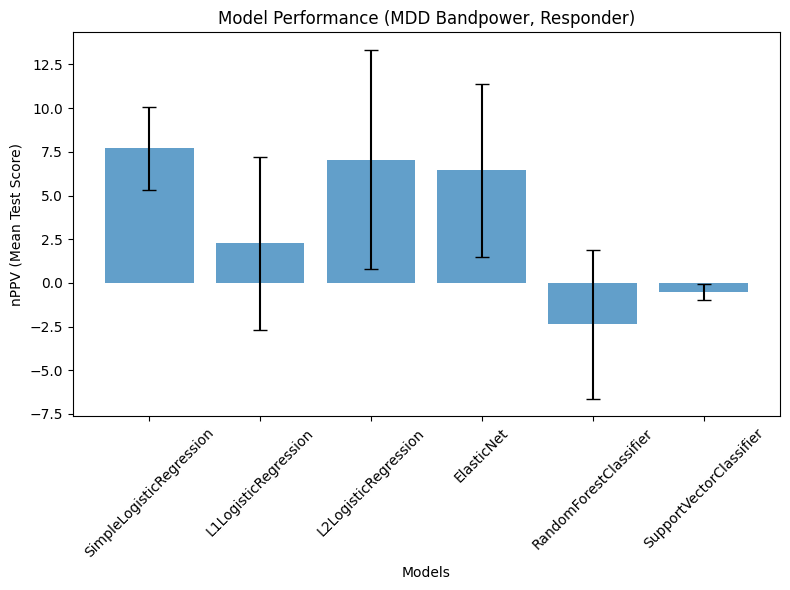

In [ ]:
# make summary plot
plt.figure(figsize=(8,6))
n_random_states=5
stderr_scores = np.array(stddev_scores) / np.sqrt(n_random_states)
bars = plt.bar(algorithms, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)

plt.xlabel('Models')
plt.ylabel(f'{eval_metric_cap} (Mean Test Score)')
plt.title(f'Model Performance ({conditions_cap}, {response_var_cap})')
plt.xticks(rotation=45)

# add baseline for accuracy
if eval_metric == "accuracy":
    plt.axhline(y=mean_baseline, color='red', linestyle='--', linewidth=2, label=f'Mean Baseline ({mean_baseline:.2f})')
    plt.legend()

# for bar, mean in zip(bars, mean_scores):
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         height / 2,                # center vertically
#         f"{mean:.3f}",
#         ha='center',
#         va='center',
#         color='black',   
#         fontsize=9,
#     )

plt.tight_layout()
plt.savefig(f"../../figures/{response_var}_{conditions}_{eval_metric}.png", format="png", dpi=300)
plt.show()

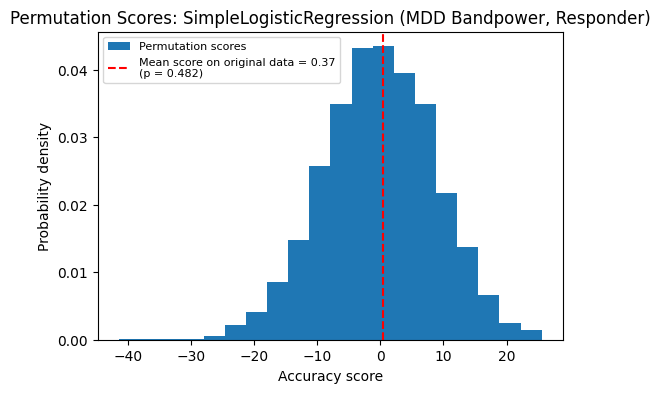

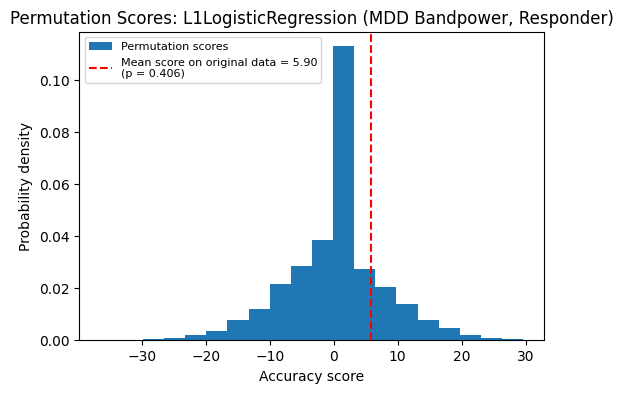

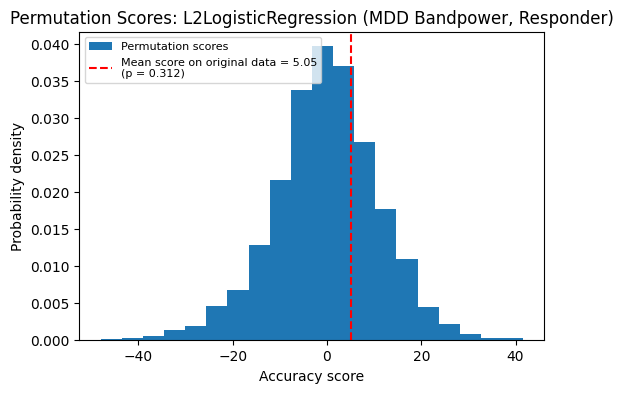

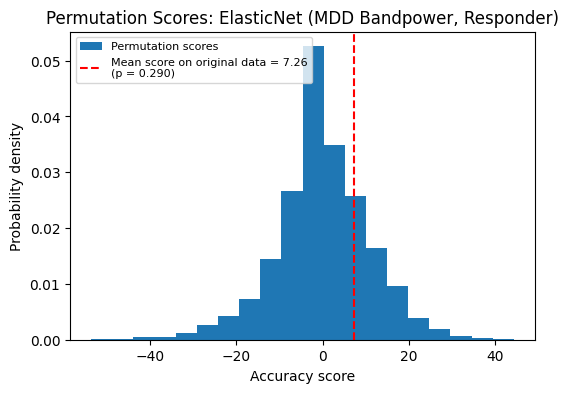

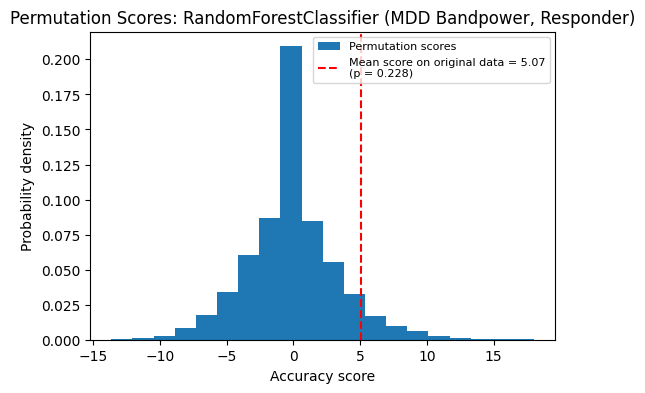

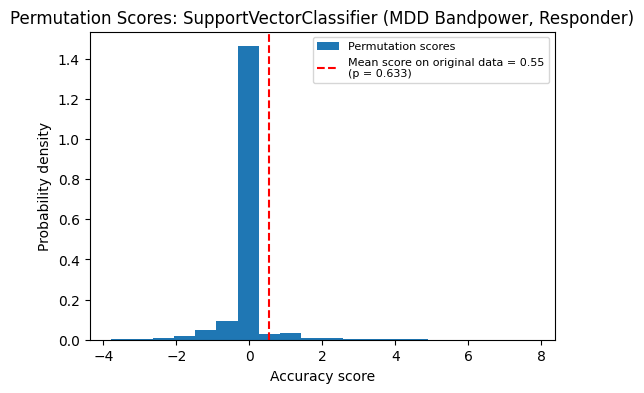

In [98]:
# generate permutation plots
# plot_permutation_results(perm_plot_data, "MDD Remitter")
title_suffix = f"{conditions_cap}, {response_var_cap}"
for model_name, (cv_scores, perm_scores_list, p_values) in perm_plot_data.items():

        cv_score = np.mean(cv_scores)
        perm_scores = np.concatenate(perm_scores_list)
        p_value = np.mean(p_values)

        plt.figure(figsize=(6,4))
        plt.hist(perm_scores, bins=20, density=True, label="Permutation scores")

        plt.axvline(
            cv_score,
            ls="--",
            color="r",
            label=f"Mean score on original data = {cv_score:.2f}\n(p = {p_value:.3f})"
        )

        plt.legend(fontsize=8)
        plt.xlabel(f"{eval_metric_cap} score")
        plt.ylabel("Probability density")
        plt.title(f"Permutation Scores: {model_name} ({title_suffix})")

        plt.show()

### Interpretability

In [102]:
file = open(f'../../results/{conditions}/SimpleLogisticRegression_{eval_metric}_{response_var}.save', 'rb')
# file = open(f'../../results/{conditions}/L1LogisticRegression_accuracy_{response_var}.save', 'rb')
best_models, test_scores = pickle.load(file)
file.close()

# get best model
top_one_index = np.argsort(test_scores)[-1:][0]  
best_model = best_models[top_one_index]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

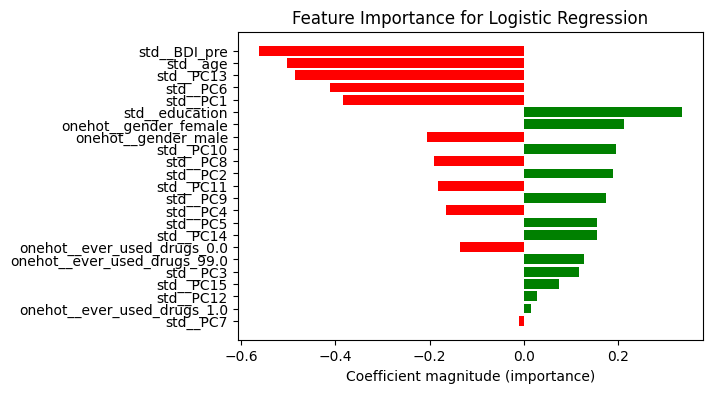

In [103]:
feat_imp = interpretability.get_logreg_feature_importance(best_model)
interpretability.plot_logreg_feature_importance(feat_imp)

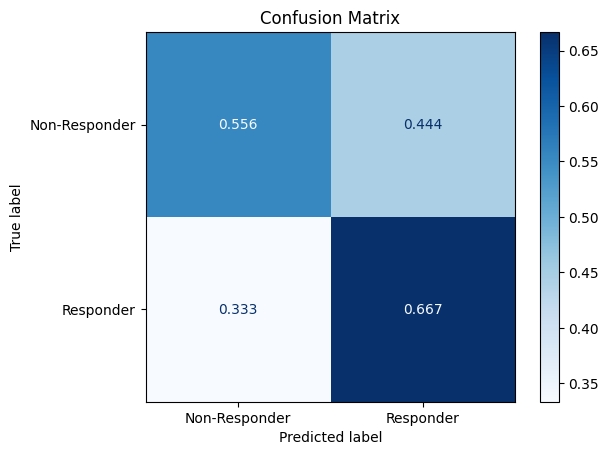

In [104]:
# display confusion matrix
class_labels = [f"Non-{response_var_cap}", response_var_cap]
# plot_confusion_matrix(best_model, X_test, y_test, class_labels)
model = best_model
title = "Confusion Matrix"
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp.plot(values_format='.3f', cmap=plt.cm.Blues)
plt.title(title)
plt.show()